# Random circuits III: non-Abelian SU(2) data

**Manuscript map.** Sec. III G 2, Fig. 11, Eq. (79).

This notebook analyzes an actual $N_s=8,N_e=12$ simulation. Every
realization evolves two complex state vectors of length $2^{20}$
through the original partial-swap brickwork gates, then constructs
all five Eq. (79) states by linearity. The relative entropy of
asymmetry is evaluated with the exact SU(2) Schur decomposition, not
a finite Monte Carlo group average.

Three complete realizations are stored. This matches the manuscript
Hilbert-space size but not its 100-realization ensemble, so the
notebook distinguishes facts present in these data from claims that
require the production run.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import circuit_data as cd
import notebook_utils as nu

np.set_printoptions(precision=5, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (7.2, 4.2),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "font.size": 11,
})

BLUE = "#394F87"
ORANGE = "#E8792E"
GOLD = "#F4C95D"
PALETTE_3 = [BLUE, ORANGE, GOLD]
PALETTE_5 = plt.cm.Oranges(np.linspace(0.35, 0.95, 5))


def load_npz(path):
    with np.load(path, allow_pickle=False) as stored:
        return {name: stored[name] for name in stored.files}


## 1. Load the long state-vector run

`REGENERATE_DATA=True` reruns the three exact-size realizations and
can take several minutes. `--paper-scale` raises the ensemble to 100
and is intended for HPC use.


In [2]:
DATA_PATH = Path("data/circuit_examples/su2_nonmarkovian.npz")
REGENERATE_DATA = False

if REGENERATE_DATA:
    generated = cd.generate_su2_nonmarkovian()
    cd.save_dataset(DATA_PATH, generated)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} is missing. Run "
        "`python tools/generate_circuit_data.py --only su2`."
    )
data = load_npz(DATA_PATH)
asymmetry = data["asymmetry"]
times = data["times"]
theta_over_pi = data["theta_over_pi"]
labels = [fr"$\theta={theta:.2f}\pi$" for theta in theta_over_pi]

print(data["protocol"].item())
print(data["data_level"].item())
print(
    f"Ns={data['n_system'].item()}, "
    f"Ne={data['n_environment'].item()}, "
    f"R={data['n_realizations'].item()}, "
    f"T={times[-1]}"
)
print("raw asymmetry array:", asymmetry.shape)
print(
    "coupling range: [-pi/5, pi/5]; "
    "environment: product of singlets"
)

assert asymmetry.shape == (
    int(data["n_realizations"]), 5, len(times)
)
assert np.isfinite(asymmetry).all()


SU(2) non-Markovian brickwork, Eq. (79)
manuscript system size; reduced ensemble (paper R=100)
Ns=8, Ne=12, R=3, T=100
raw asymmetry array: (3, 5, 101)
coupling range: [-pi/5, pi/5]; environment: product of singlets


## 2. Exact SU(2) twirl

The initial state and environment are

$$
|\varphi(\theta)\rangle =
\cos(\theta/2)|\xi\rangle^{\otimes N_s/2}
+\sin(\theta/2)|0\rangle^{\otimes N_s},\qquad
|\pi_e\rangle=|\xi\rangle^{\otimes N_e/2},
$$

where $|\xi\rangle=(|01\rangle-|10\rangle)/\sqrt2$. The Hilbert
space decomposes as
$\mathcal H_s=\bigoplus_j\mathcal M_j\otimes\mathcal V_j$.
SU(2) twirling preserves the multiplicity state and replaces each
spin-$j$ irrep by $I_{2j+1}/(2j+1)$. The data generator therefore
evaluates

$$
M_{\rm SU(2)}(\rho_s)
=S(\mathcal G_{\rm SU(2)}[\rho_s])-S(\rho_s)
$$

exactly in the coupled-spin basis.


In [3]:
print("Schur multiplicities (2j -> multiplicity):")
print(
    dict(
        zip(
            data["spin_twice"].tolist(),
            data["multiplicity"].tolist(),
        )
    )
)

# At t=0 the system is pure and occupies j=0 plus
# |j=Ns/2,m=j>. This gives an analytic entropy check.
p_polarized = np.sin(theta_over_pi * np.pi / 2) ** 2
binary_entropy = -(
    p_polarized * np.log(p_polarized)
    + (1 - p_polarized) * np.log(1 - p_polarized)
)
analytic_initial = (
    binary_entropy
    + p_polarized * np.log(int(data["n_system"]) + 1)
)
measured_initial = asymmetry[:, :, 0].mean(axis=0)

print("analytic M(0):", analytic_initial)
print("stored   M(0):", measured_initial)
assert np.allclose(
    measured_initial, analytic_initial, atol=1e-11
)


Schur multiplicities (2j -> multiplicity):
{0: 14, 2: 28, 4: 20, 6: 7, 8: 1}
analytic M(0): [0.96162 1.18608 1.40373 1.60761 1.79176]
stored   M(0): [0.96162 1.18608 1.40373 1.60761 1.79176]


## 3. Visualize every stored realization

There are only three curves per angle, so an opaque error bar would
overstate the statistics. The left panel shows every realization;
the right panel shows their mean and full min-max range.


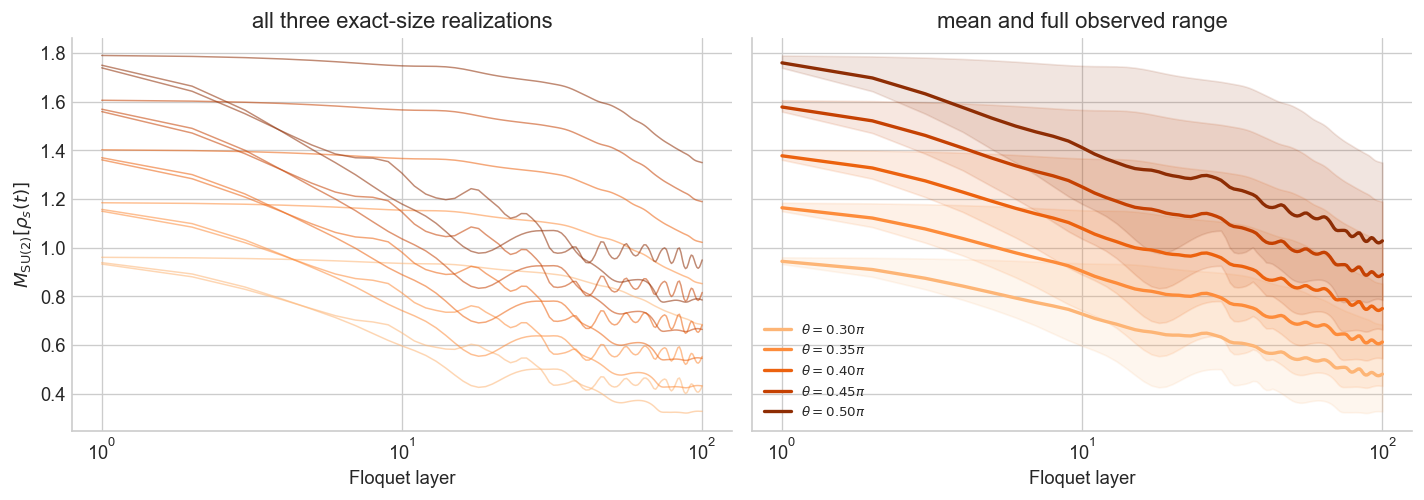

In [4]:
mean_curves = asymmetry.mean(axis=0)
minimum_curves = asymmetry.min(axis=0)
maximum_curves = asymmetry.max(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), sharey=True)
for state_index, (label, color) in enumerate(
    zip(labels, PALETTE_5)
):
    for realization in range(asymmetry.shape[0]):
        axes[0].plot(
            times[1:],
            asymmetry[realization, state_index, 1:],
            color=color,
            alpha=0.55,
            lw=0.9,
        )
    axes[1].plot(
        times[1:],
        mean_curves[state_index, 1:],
        color=color,
        lw=2,
        label=label,
    )
    axes[1].fill_between(
        times[1:],
        minimum_curves[state_index, 1:],
        maximum_curves[state_index, 1:],
        color=color,
        alpha=0.12,
    )

for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel("Floquet layer")
axes[0].set(
    ylabel=r"$M_{\rm SU(2)}[\rho_s(t)]$",
    title="all three exact-size realizations",
)
axes[1].set(title="mean and full observed range")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()


## 4. What these data do—and do not—establish

We test all pairwise mean-curve crossings and quantify
non-Markovian revivals. A missing crossing is reported as such; it is
not replaced by an illustrative curve. With three realizations, the
stored run verifies the full protocol and backflow but is not a
statistically converged reproduction of the 100-realization Fig. 11
average.


In [5]:
finite_crossings = []
for high in range(1, len(theta_over_pi)):
    for low in range(high):
        tau = nu.crossing_time(
            times, mean_curves[high], mean_curves[low]
        )
        if np.isfinite(tau):
            finite_crossings.append(
                (theta_over_pi[high], theta_over_pi[low], tau)
            )

if finite_crossings:
    for high, low, tau in finite_crossings:
        print(
            f"theta={high:.2f}pi crosses "
            f"theta={low:.2f}pi at t={tau:.2f}"
        )
else:
    print(
        "No pairwise crossing in the three-realization mean."
    )

increments = np.diff(asymmetry, axis=-1)
print(
    "largest raw one-step revival:", increments.max()
)
print(
    "fraction of raw steps with positive increment:",
    (increments > 1e-10).mean(),
)
assert increments.max() > 0


No pairwise crossing in the three-realization mean.
largest raw one-step revival: 0.029588055078682896
fraction of raw steps with positive increment: 0.252


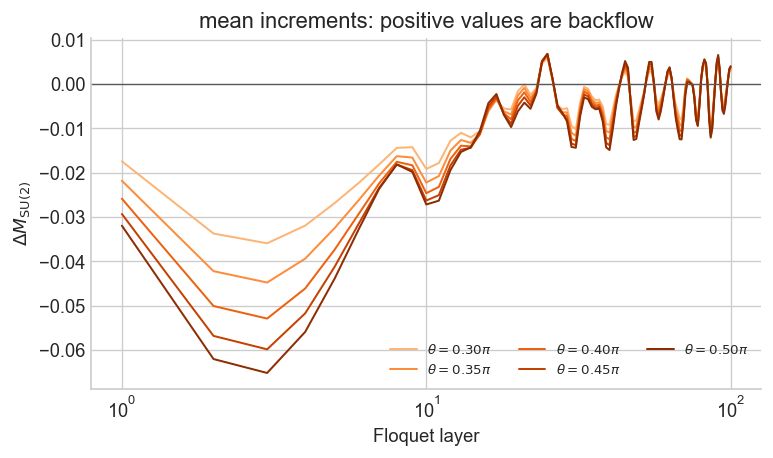

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
for state_index, (label, color) in enumerate(
    zip(labels, PALETTE_5)
):
    ax.plot(
        times[1:],
        np.diff(mean_curves[state_index]),
        color=color,
        lw=1.2,
        label=label,
    )
ax.axhline(0, color="0.35", lw=0.8)
ax.set(
    xscale="log",
    xlabel="Floquet layer",
    ylabel=r"$\Delta M_{\rm SU(2)}$",
    title="mean increments: positive values are backflow",
)
ax.legend(ncol=3, fontsize=8)
plt.show()


## Takeaway

This is an auditable separation between protocol validation and
production statistics. The notebook executes the exact symmetry
construction and visualizes real $2^{20}$ data. It demonstrates
SU(2)-covariant relaxation and finite-environment revivals. The
published ensemble crossing must be assessed with the 100-circuit
run; this three-circuit file is intentionally not presented as a
substitute for it.
